### **Import Library**

In [1]:
import sys
print(sys.executable)

d:\PENS 2024\SEMESTER 4\PBL\venv_py310\Scripts\python.exe


In [2]:
# Jalankan ini jika belum install ydata-profiling:
# !pip install ydata-profiling seaborn matplotlib pandas

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings

# Mengabaikan warning agar output notebook tetap rapi
warnings.filterwarnings('ignore')

# Set tema visualisasi
sns.set_theme(style="whitegrid")

d:\PENS 2024\SEMESTER 4\PBL\venv_py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\putuw\AppData\Local\Temp\ipykernel_21232\3877493728.py:8: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


### **Koneksi dan Ekstraksi Data Mentah**

In [3]:
print("Memuat data mentah dari SQLite...")
conn = sqlite3.connect('../data/raw/siskaperbapo.db')
df_raw = pd.read_sql_query("SELECT * FROM harga_bahan_pokok", conn)
conn.close()

# Menampilkan informasi dasar dataframe
print(f"Total Baris: {df_raw.shape[0]}")
print(f"Total Kolom: {df_raw.shape[1]}")
df_raw.info()

# Mengintip 5 baris pertama
display(df_raw.head())

Memuat data mentah dari SQLite...
Total Baris: 158862
Total Kolom: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158862 entries, 0 to 158861
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              158862 non-null  int64  
 1   tanggal_scrape  158862 non-null  object 
 2   tanggal_data    158862 non-null  object 
 3   komoditas       158862 non-null  object 
 4   satuan          158862 non-null  object 
 5   harga_rp        158862 non-null  float64
 6   kabkota         158862 non-null  object 
 7   created_at      158862 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 9.7+ MB


,id,tanggal_scrape,tanggal_data,komoditas,satuan,harga_rp,kabkota,created_at
0,1,2021-04-25,2021-04-25,BERAS,,0.0,Surabaya,2026-04-25 13:56:29
1,2,2021-04-25,2021-04-25,- Beras Premium,kg,14870.0,Surabaya,2026-04-25 13:56:29
2,3,2021-04-25,2021-04-25,- Beras Medium,kg,12928.0,Surabaya,2026-04-25 13:56:29
3,4,2021-04-25,2021-04-25,GULA,,0.0,Surabaya,2026-04-25 13:56:29
4,5,2021-04-25,2021-04-25,- Gula Kristal Putih,kg,17293.0,Surabaya,2026-04-25 13:56:29


### **Pandas Profiling (Automated EDA)**

In [4]:
print("Mulai membuat laporan Pandas Profiling. Tunggu sebentar...")

# explorative=True akan melakukan analisis yang lebih mendalam
profile = ProfileReport(df_raw, title="MarketCast Raw Data Profiling", explorative=True)

# Menyimpan hasil ke file HTML
profile.to_file("marketcast_raw_eda_report.html")

print("✅ Laporan HTML berhasil dibuat! Silakan buka 'marketcast_raw_eda_report.html' di browser.")

# Jika ingin menampilkannya langsung di dalam notebook (opsional):
# profile.to_notebook_iframe()

Mulai membuat laporan Pandas Profiling. Tunggu sebentar...


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 216.11it/s]

✅ Laporan HTML berhasil dibuat! Silakan buka 'marketcast_raw_eda_report.html' di browser.


### **Manual EDA - Analisis Distribusi**

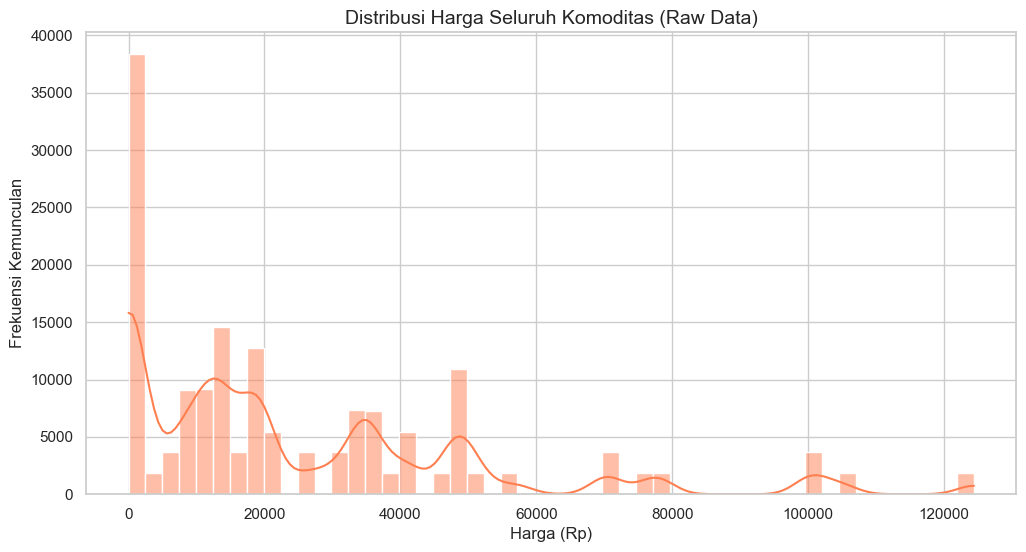

Insight: Terdapat 36520 baris (22.99%) dengan harga Rp 0.
Ini memvalidasi perlunya penghapusan baris harga 0 di tahap Preprocessing.


In [12]:
%matplotlib inline

plt.figure(figsize=(12, 6))

# Kita plotting distribusi harga. 
sns.histplot(df_raw['harga_rp'], bins=50, kde=True, color='coral')

plt.title('Distribusi Harga Seluruh Komoditas (Raw Data)', fontsize=14)
plt.xlabel('Harga (Rp)', fontsize=12)
plt.ylabel('Frekuensi Kemunculan', fontsize=12)

# Mengatur format angka di sumbu X agar lebih mudah dibaca
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Mencetak bukti matematis
jumlah_nol = len(df_raw[df_raw['harga_rp'] == 0])
persentase_nol = (jumlah_nol / len(df_raw)) * 100
print(f"Insight: Terdapat {jumlah_nol} baris ({persentase_nol:.2f}%) dengan harga Rp 0.")
print("Ini memvalidasi perlunya penghapusan baris harga 0 di tahap Preprocessing.")

### **Manual EDA - Deteksi Outlier (Boxplot)**

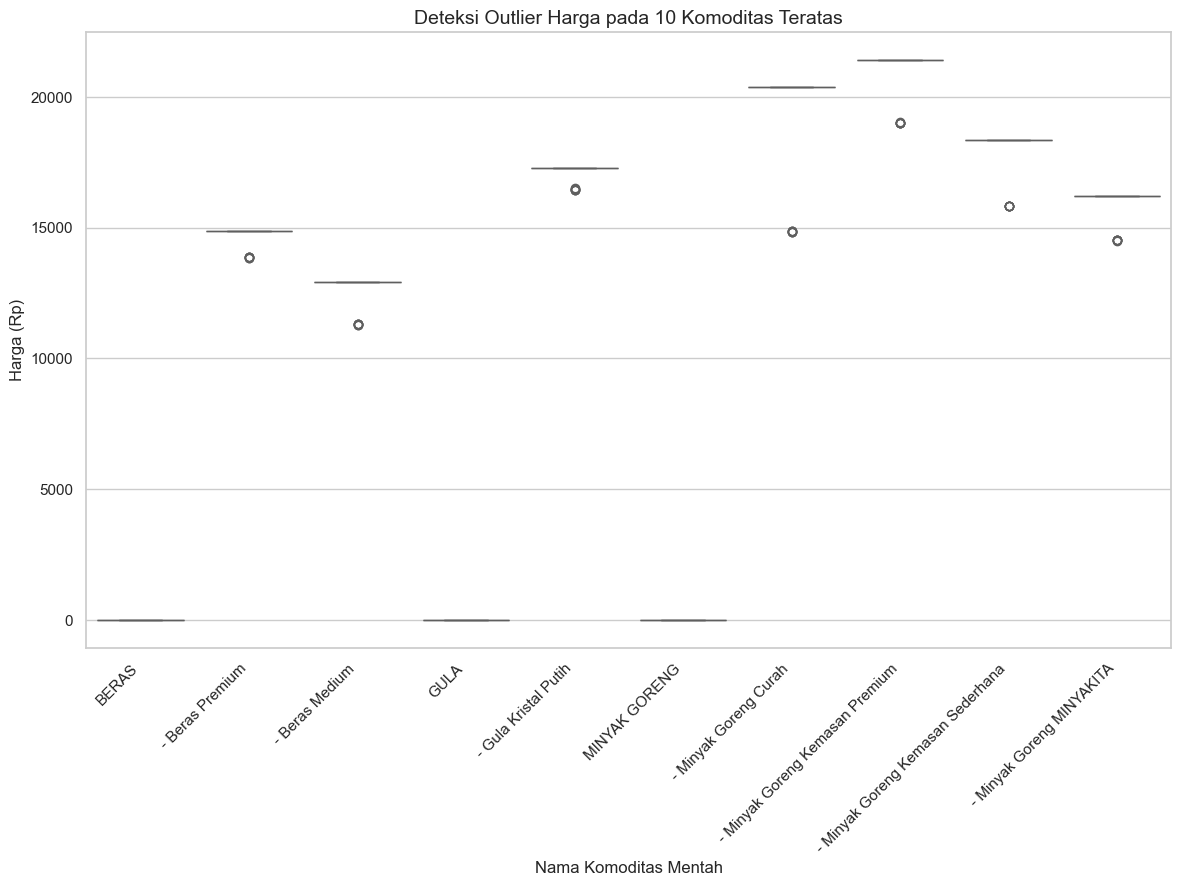

Insight: Perhatikan nama komoditas di sumbu X. Terdapat nama yang diawali dengan tanda hubung atau nomor.
Perhatikan juga titik-titik di luar kotak (outliers) yang menandakan fluktuasi harga ekstrem atau salah ketik dari sumber data.


In [13]:
%matplotlib inline

plt.figure(figsize=(14, 8))

# Mengambil 10 nama komoditas mentah yang paling sering muncul
top_10_komoditas = df_raw['komoditas'].value_counts().nlargest(10).index
df_sampel = df_raw[df_raw['komoditas'].isin(top_10_komoditas)]

# Membuat Boxplot
sns.boxplot(data=df_sampel, x='komoditas', y='harga_rp', palette='Set3')

plt.title('Deteksi Outlier Harga pada 10 Komoditas Teratas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Nama Komoditas Mentah', fontsize=12)
plt.ylabel('Harga (Rp)', fontsize=12)
plt.show()

print("Insight: Perhatikan nama komoditas di sumbu X. Terdapat nama yang diawali dengan tanda hubung atau nomor.")
print("Perhatikan juga titik-titik di luar kotak (outliers) yang menandakan fluktuasi harga ekstrem atau salah ketik dari sumber data.")

### **Manual EDA - Pengecekan Duplikasi**

In [15]:
%matplotlib inline

# 1. Cek duplikasi baris secara keseluruhan
total_duplikat = df_raw.duplicated().sum()
print(f"Total baris duplikat persis: {total_duplikat}")

# 2. Cek konsistensi tanggal
df_raw['tanggal_data_dt'] = pd.to_datetime(df_raw['tanggal_data'], errors='coerce')
tanggal_awal = df_raw['tanggal_data_dt'].min().date()
tanggal_akhir = df_raw['tanggal_data_dt'].max().date()

print(f"\nRentang Data Historis: {tanggal_awal} hingga {tanggal_akhir}")

Total baris duplikat persis: 0

Rentang Data Historis: 2021-04-25 hingga 2026-04-25


### **Manual EDA - Pengecekan Korelasi/Hubungan Antar Fitur**

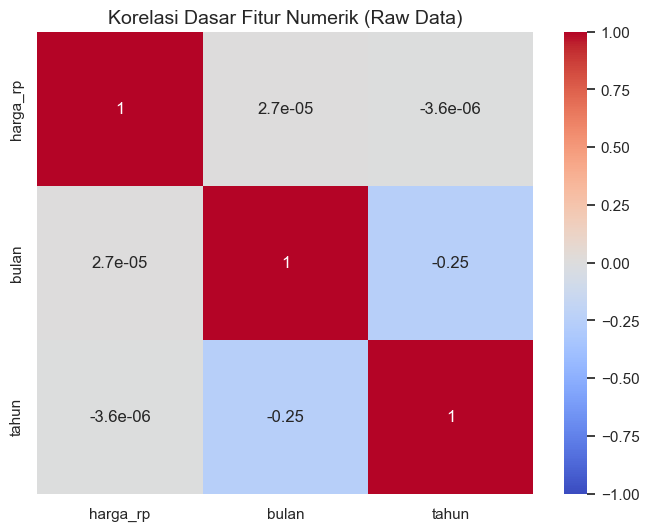

In [16]:
# 1. Cek korelasi dasar antar kolom numerik (Meski di raw data hanya ada harga_rp)
# Kita tambahkan fitur waktu sementara untuk melihat heatmaps
df_raw['bulan'] = df_raw['tanggal_data_dt'].dt.month
df_raw['tahun'] = df_raw['tanggal_data_dt'].dt.year

plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[['harga_rp', 'bulan', 'tahun']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Dasar Fitur Numerik (Raw Data)', fontsize=14)
plt.show()